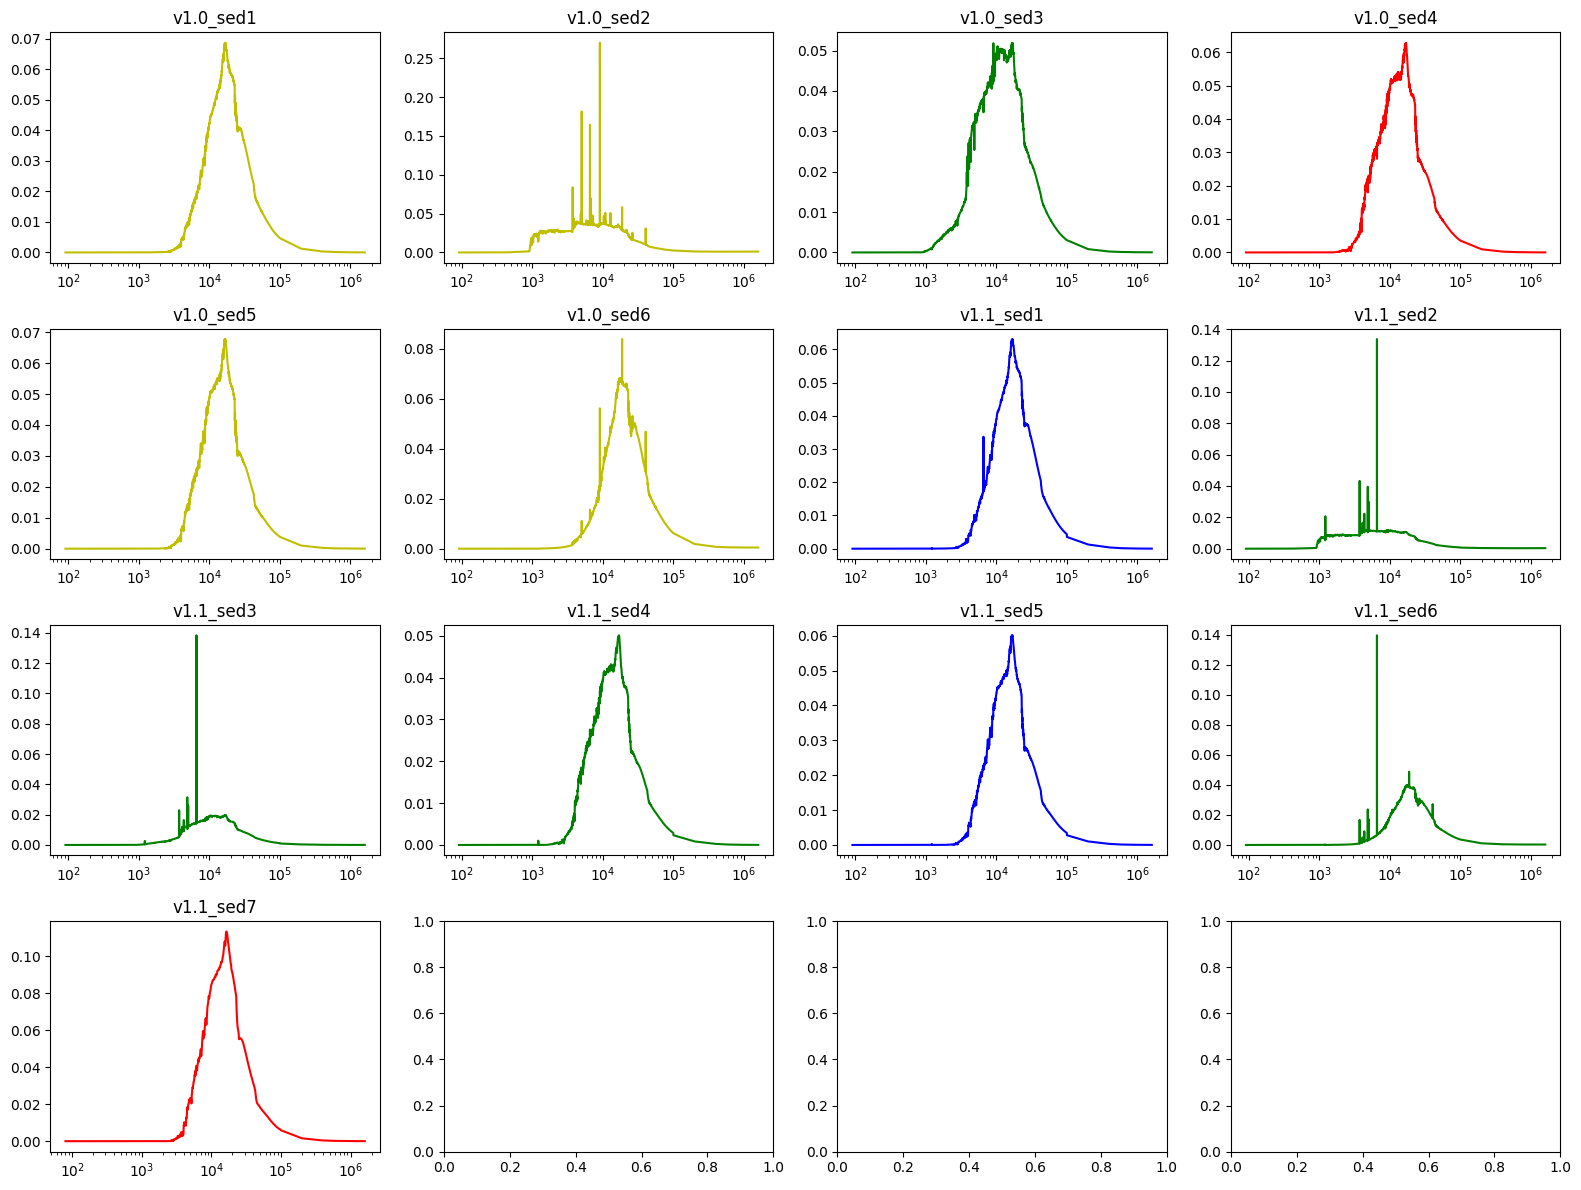

In [10]:
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
f=glob('eazy*')
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
p=['r','b','g','y']
wave1={}
norm_flux1={}
for idx, i in enumerate(f):
    wave, flux = np.loadtxt(i, unpack=True)
    flux *= wave**2. / 3e18
    norm=np.sqrt(np.sum(flux**2))
    norm_flux=flux/norm
    wave1[i]=wave
    norm_flux1[i]=norm_flux
    ax = axes[idx]
    ax.plot(wave, norm_flux,color=np.random.choice(p))
    ax.set_title(i[-13:-4])
    #ax.set_xlim(0,20000)
    ax.set_xscale('log')




plt.tight_layout()
plt.show()


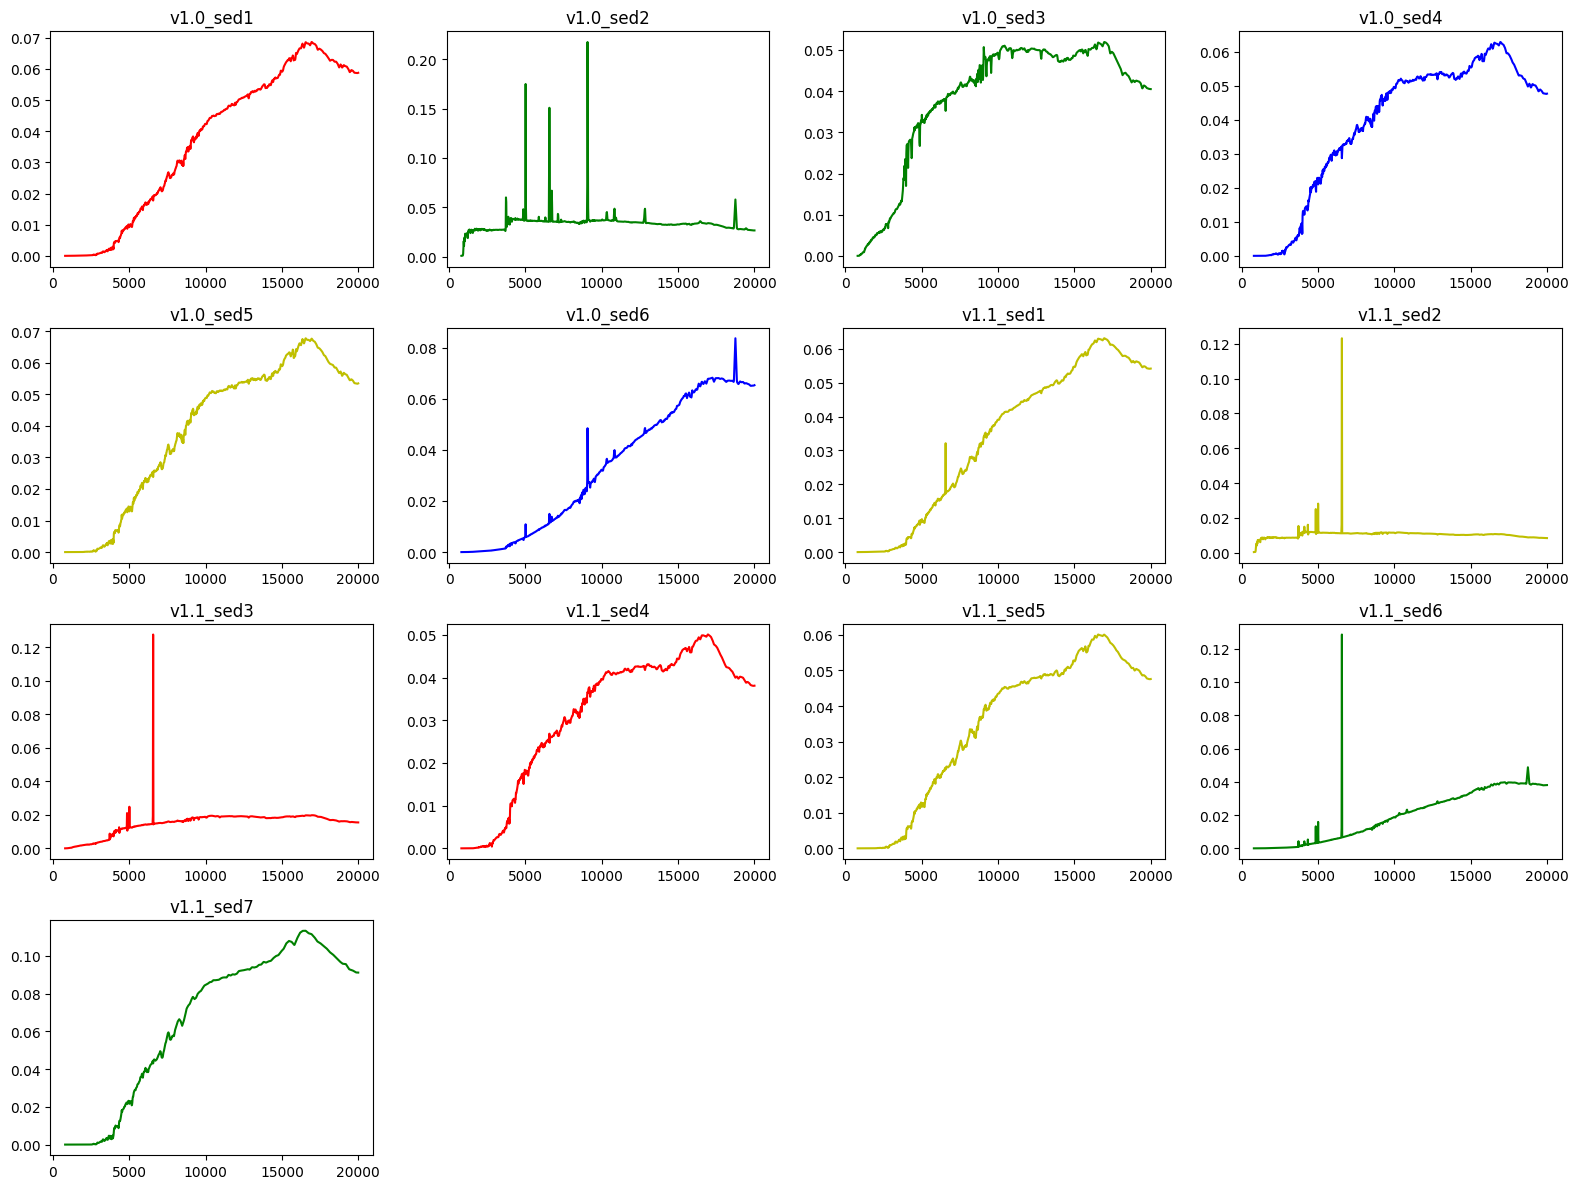

In [11]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
p=['r','b','g','y']
wave_grid = np.linspace(800, 20000, 1000)
norm_flux_interp={}
for idx, i in enumerate(wave1.keys()):
    norm_flux_int = np.interp(wave_grid, wave1[i], norm_flux1[i])
    norm_flux_interp[i]=norm_flux_int
    ax = axes[idx]
    ax.plot(wave_grid, norm_flux_int,color=np.random.choice(p))
    ax.set_title(i[-13:-4])
    #ax.set_xscale('log')

for idx in range(len(f), len(axes)):
    axes[idx].axis('off')


plt.tight_layout()
plt.show()

In [12]:
import numpy as np
from scipy.special import factorial, gamma as func_gamma, gammaincc as func_gammaincc

linewv = np.array([1215.67, 1025.72, 972.537, 949.743, 937.803, 930.748, 926.226,
                    923.150, 920.963, 919.352, 918.129, 917.181, 916.429, 915.824, 915.329, 914.919, 914.576, 914.286, 914.039, 913.826, 913.641, 913.480, 913.339, 913.215, 913.104, 913.006, 912.918, 912.839, 912.768, 912.703, 912.645, 912.592, 912.543, 912.499, 912.458, 912.420, 912.385, 912.353, 912.324])
Rn = np.array([1.00000000e+00, 2.77633136e-01, 1.32485207e-01,
                    7.80473373e-02, 5.15207101e-02, 3.65562130e-02, 
                    2.72721893e-02, 2.11183432e-02, 1.68224852e-02, 
                    1.37159763e-02, 1.13786982e-02, 9.59763314e-03, 
                    8.19526627e-03, 7.07692308e-03, 6.17159763e-03, 
                    5.42840237e-03, 4.80946746e-03, 4.29053254e-03, 
                    3.84911243e-03, 3.47218935e-03, 3.14733728e-03, 
                    2.86568047e-03, 2.61952663e-03, 2.40414201e-03, 
                    2.21183432e-03, 2.04378698e-03, 1.89289941e-03, 
                    1.75798817e-03, 1.63668639e-03, 1.52781065e-03, 
                    1.42899408e-03, 1.33905325e-03, 1.25798817e-03, 
                    1.18343195e-03, 1.11538462e-03, 1.05266272e-03, 
                    9.95266272e-04, 9.42603550e-04, 8.93491124e-04])[:,None]

def tau_eff(z):
    z_1= 1.2593846589041013
    a_1= 1.405759341921824
    A1= 0.01549433546364817
    z_2= 5.174708845486191
    a_2= 3.6336748056970474
    a_3= 7.587297773671628
    delta= 0.030496534844542546
    A2=2.0448040499201565

    return np.piecewise(z,[z<z_1, z>=z_1], [lambda x:A1*((1.+x))**a_1, lambda z:A2*((1.+z)/(1.+z_2))**(a_2)*(0.5*(1.+((1.+z)/(1.+z_2))**(1./delta)))**(delta*(a_3-a_2))])

def tau_eff_highz(z):
    z_2= 5.174708845486191
    a_2= 3.6336748056970474
    a_3= 7.587297773671628
    delta= 0.030496534844542546
    A2=2.0448040499201565
    return A2*((1.+z)/(1.+z_2))**(a_2)*(0.5*(1.+((1.+z)/(1.+z_2))**(1./delta)))**(delta*(a_3-a_2))

def tau_lc_igm(zs, l_obs):
    lratio = l_obs/911.8
    tau_igm = 0.805*lratio**3. * (1/lratio - 1/(1+zs))
    return tau_igm

def tau_lc_lls(zs, l_obs, n0=0.15, beta=1.28, gamma=1.94, nterms = 10):
    lratio = l_obs/911.8 #ratio of observed wavelength to lyman limit, also z_LLS
    zs_p1 = 1+zs
    e_neg1 = 0.36787944117144233  #1/e
    if beta==1.28 and gamma==1.94:
        beta_m1 = 0.28
        gamma_p1 = 2.94
        gam_fn = 0.31340445237536
    else:
        gamma_p1 = gamma + 1
        beta_m1 = beta - 1
        gam_fn = func_gamma(2-beta,1)*func_gammaincc(2-beta,1)
        
    sum1 = _first_lls_sum(beta_m1,nterms)
    sum2 = _second_lls_sum(zs_p1, lratio, gamma_p1=gamma_p1, beta_m1=beta_m1, nterms=nterms)
    tau_lls = n0/(4+gamma-3*beta) * (gam_fn - e_neg1 - sum1) * ( zs_p1**(-3*beta_m1+gamma_p1) * lratio**(3*beta_m1) - np.power(lratio,gamma_p1)) - n0*sum2
    return tau_lls

def _first_lls_sum(beta_m1=0.28, nterms=10):
    #if default beta, nterms return precomputed
    if beta_m1 == 0.28 and nterms==10:
        return -1.3219480209375662
    else:
        # sums from n=0
        n = np.arange(0,nterms)
        return np.sum( (beta_m1) / (n - beta_m1) * (-1)**n / factorial(n) )

def _second_lls_sum(zs_p1, lratio, gamma_p1=2.94, beta_m1=0.28, nterms=10):
    # sums from n=1
    n = np.arange(1,1+nterms)[:,None] 
    if beta_m1 ==0.28 and gamma_p1 == 2.94 and nterms==10:
        gamma_3n_p1 = np.array([ 0.06,  3.06,  6.06,  9.06, 12.06, 15.06, 18.06, 21.06, 24.06,27.06])[:,None]
        term1 = np.array([-6.48148148e+00,  2.65997872e-02, -2.83116547e-03,
         3.46159020e-04, -4.09909024e-05,  4.51444675e-06,
        -4.57762778e-07,  4.27131736e-08, -3.67775581e-09,
         2.93360030e-10])[:,None]
    else:
        gamma_3n_p1 = 3*n - gamma_p1
        term1 = beta_m1 * (-1)**n / ( (gamma_3n_p1) * (n-beta_m1) * factorial(n) )
    term2 = zs_p1**(-gamma_3n_p1) * np.power(lratio, 3*n) - np.power(lratio,gamma_p1)
    return np.sum(term1*term2,axis=0)

def calc_transmission(z_s,l_obs,model='full', nlines = 30, z_lls=None):
    if z_lls is not None:
        if z_lls>z_s:
            raise ValueError('z_lls must be less than or equal to z_s or None')
    if nlines>39:
        raise ValueError('Maximum value for nlines is 39.')
    if model=='full':
        tau_lya = tau_eff
    elif model=='highz':
        tau_lya = tau_eff_highz
    elif model=='optimise':
        zbreak = 1.26
        if np.any(l_obs<zbreak):
            tau_lya = tau_eff
        else:
            tau_lya = tau_eff_highz
    zlook = np.outer(1./linewv[0:nlines],l_obs)-1
    tau_laf_i = np.zeros_like(zlook)
    mask_lya = zlook<z_s
    tau_laf_i[mask_lya] = tau_lya(zlook[mask_lya])
    tau_laf_i *= Rn[0:nlines]
    tau_lys = np.sum(tau_laf_i,axis=0)

    mask_lc = l_obs<911.8*(1.+z_s)
    tau_lc = np.zeros_like(l_obs)
    tau_lc[mask_lc] = tau_lc_igm(z_s,l_obs[mask_lc])

    tau_lls = np.zeros_like(l_obs)
    if z_lls is None:
        tau_lls[mask_lc] += tau_lc_lls(z_s,l_obs[mask_lc])
    else:
        lls_mask = l_obs<(911.8*(1+z_lls))
        tau_lls[lls_mask] = np.inf
    return np.exp(-(tau_lys+tau_lc+tau_lls))


<>:23: SyntaxWarning: invalid escape sequence '\A'
<>:23: SyntaxWarning: invalid escape sequence '\A'
C:\Users\pranav\AppData\Local\Temp\ipykernel_18532\993811241.py:23: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('Wavelength ($\AA$)')


Text(0, 0.5, 'Transmission')

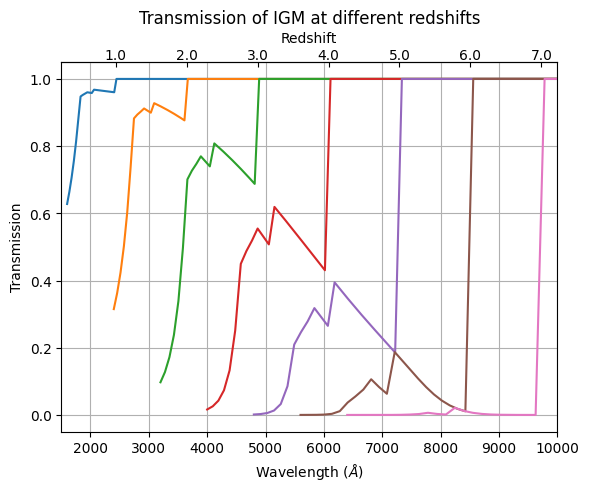

In [6]:
# plot transmission function
zrange = np.arange(1.,8.)

plt.figure()
for z in zrange:
    obswav = wave_grid*(1+z)
    trans = calc_transmission(z_s=z,l_obs=obswav)
    plt.plot(obswav, trans,lw=1.5,label=z)

ax = plt.gca()
#ax.set_yticks(fontsize=12)


g = lambda x: 1216.*(1.+x)
f = lambda x: x/1216.-1.

ax2 = ax.secondary_xaxis("top", functions=(f,g))
ax2.set_xticks(zrange)
ax2.tick_params(axis='x',direction='in',pad=0.)
ax2.set_xticklabels(zrange,)
ax2.set_xlabel('Redshift')
plt.xlim(1500,10000)
plt.xlabel('Wavelength ($\AA$)')
plt.grid()
plt.title('Transmission of IGM at different redshifts')
plt.ylabel('Transmission')

In [13]:
def calzetti_k_lambda(wave_rest):
    lam = wave_rest / 1e4  # convert to microns
    k = np.zeros_like(lam)
    mask = (lam >= 0.12) & (lam < 0.63)
    k[mask] = 2.659*(-2.156 + 1.509/lam[mask] - 0.198/lam[mask]**2 + 0.011/lam[mask]**3) + 4.05
    mask1 = (lam >= 0.63) & (lam <= 2.20)
    k[mask1] = 2.659*(-1.857 + 1.040/lam[mask1]) + 4.05
    return k

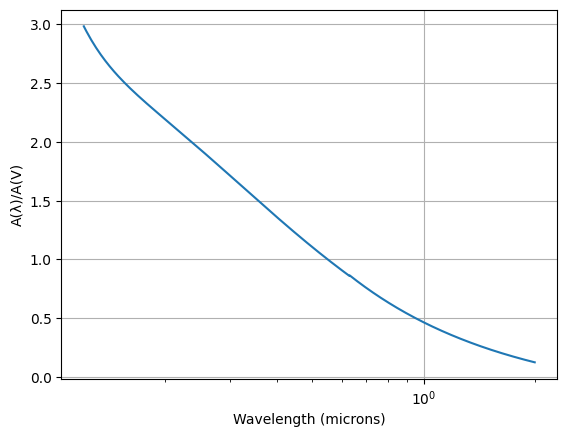

In [18]:
k_lambda = calzetti_k_lambda(wave_grid)
lam_um = wave_grid / 1e4  # convert to microns
valid = (lam_um >= 0.12) & (lam_um <= 2.2)

plt.semilogx(lam_um[valid], k_lambda[valid] / 4.05)  # normalize by A(V)
plt.xlabel("Wavelength (microns)")
plt.ylabel("A(λ)/A(V)")
plt.grid(True)


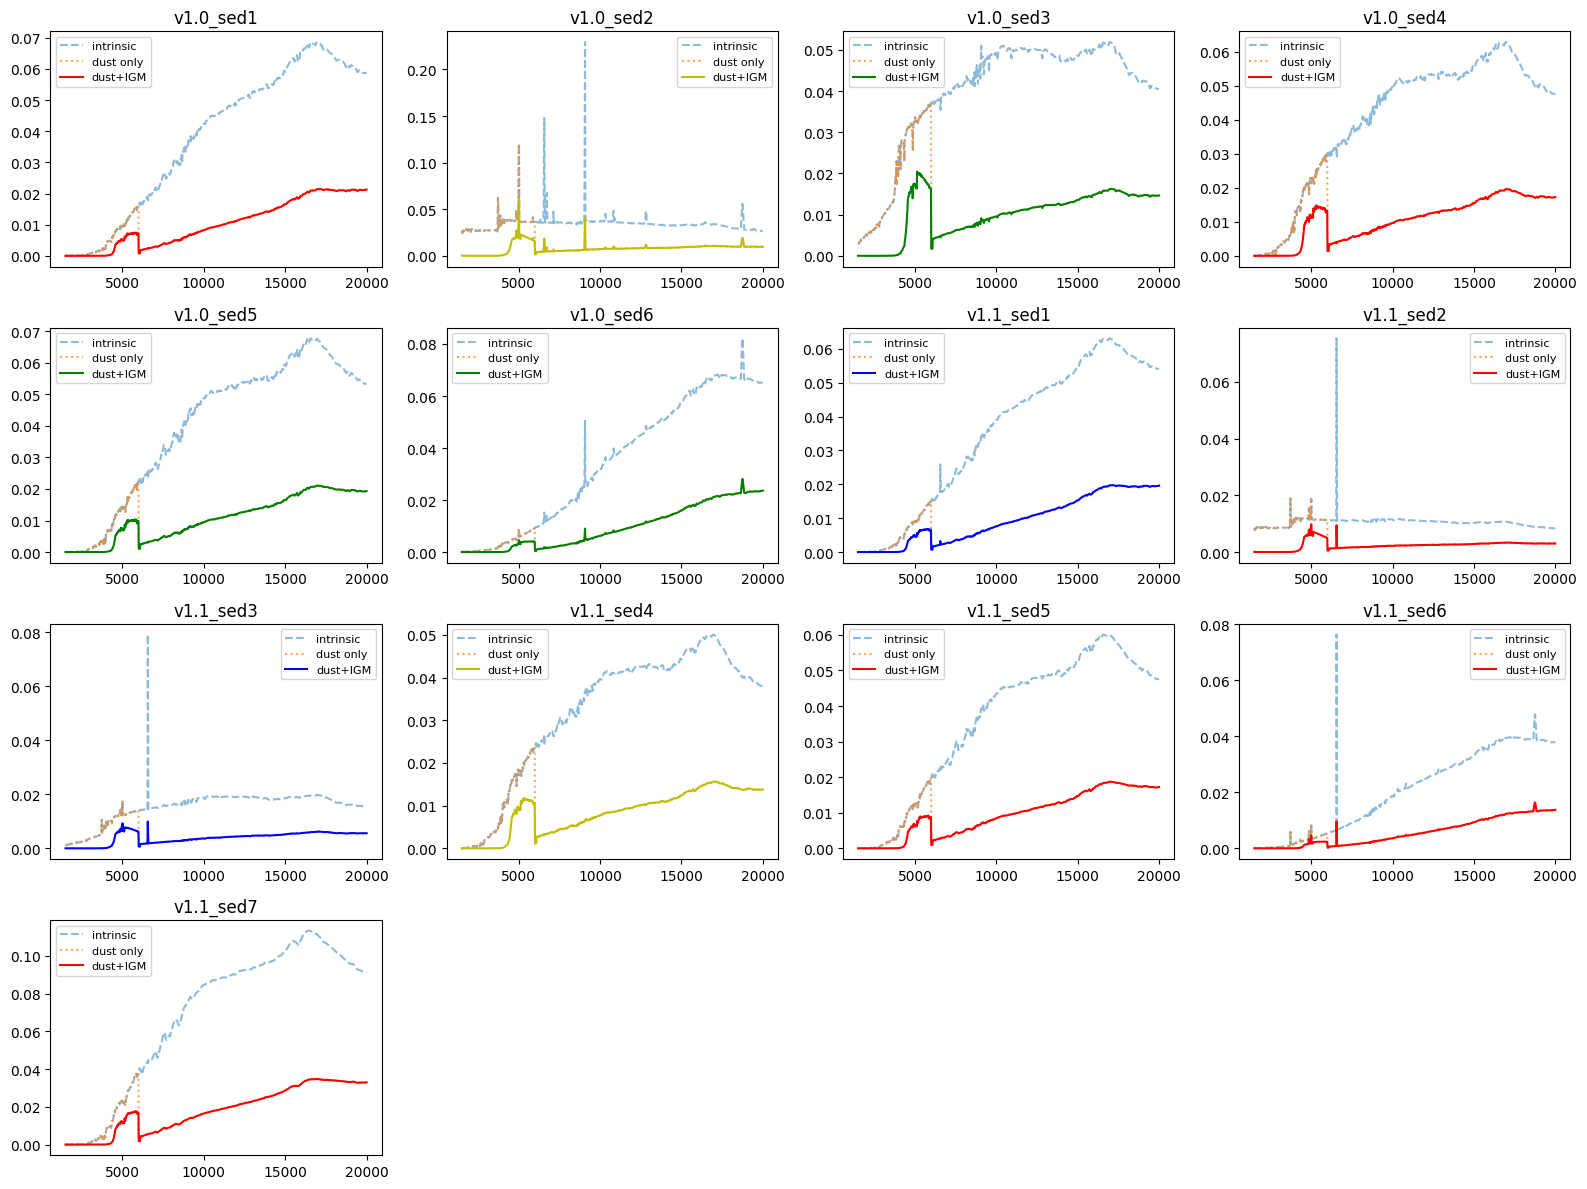

In [4]:
# -----------------
# Dust attenuation
# -----------------
def calzetti_k_lambda(wave_rest):
    """Calzetti law (Calzetti et al. 2000), R_V=4.05.
       Input wavelength in Angstroms.
       Returns k(λ) in units of mag per E(B-V)."""
    lam = wave_rest / 1e4  # convert to microns
    k = np.zeros_like(lam)
    mask = (lam >= 0.12) & (lam < 0.63)
    k[mask] = 2.659*(-2.156 + 1.509/lam[mask] - 0.198/lam[mask]**2 + 0.011/lam[mask]**3) + 4.05
    mask1 = (lam >= 0.63) & (lam <= 2.20)
    k[mask1] = 2.659*(-1.857 + 1.040/lam[mask]) + 4.05
    return k

E_BV = 0.2  # example value

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
attenuated_flux = {}

z_s = 4
trans = calc_transmission(z_s, wave_grid, model='full', nlines=30)

for idx, i in enumerate(wave1.keys()):
    # intrinsic spectrum
    flux_int = norm_flux_interp[i]

    # Dust attenuation (rest-frame)
    k_lambda = calzetti_k_lambda(wave_grid/(1+z_s))  # convert obs λ back to rest λ
    flux_dust = flux_int * 10**(-0.4 * k_lambda * E_BV)

    # Apply IGM transmission
    flux_att = flux_dust * trans
    attenuated_flux[i] = flux_att

    # plot
    ax = axes[idx]
    ax.plot(wave_grid, flux_int, ls='--', alpha=0.5, label='intrinsic')
    ax.plot(wave_grid, flux_dust, ls=':', alpha=0.7, label='dust only')
    ax.plot(wave_grid, flux_att, color=np.random.choice(p), label='dust+IGM')
    ax.set_title(i[-13:-4])
    ax.legend(fontsize=8)

# turn off unused subplots
for idx in range(len(wave1), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


In [11]:
flux_list = []
for name in norm_flux_interp.keys():
    flux_list.append(norm_flux_interp[name])

data_matrix = np.array(flux_list)

In [12]:
from sklearn.decomposition import NMF
model = NMF(4, init='random', random_state=0)
W = model.fit_transform(data_matrix)
H = model.components_

C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sklearn\decomposition\_nmf.py:1759: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


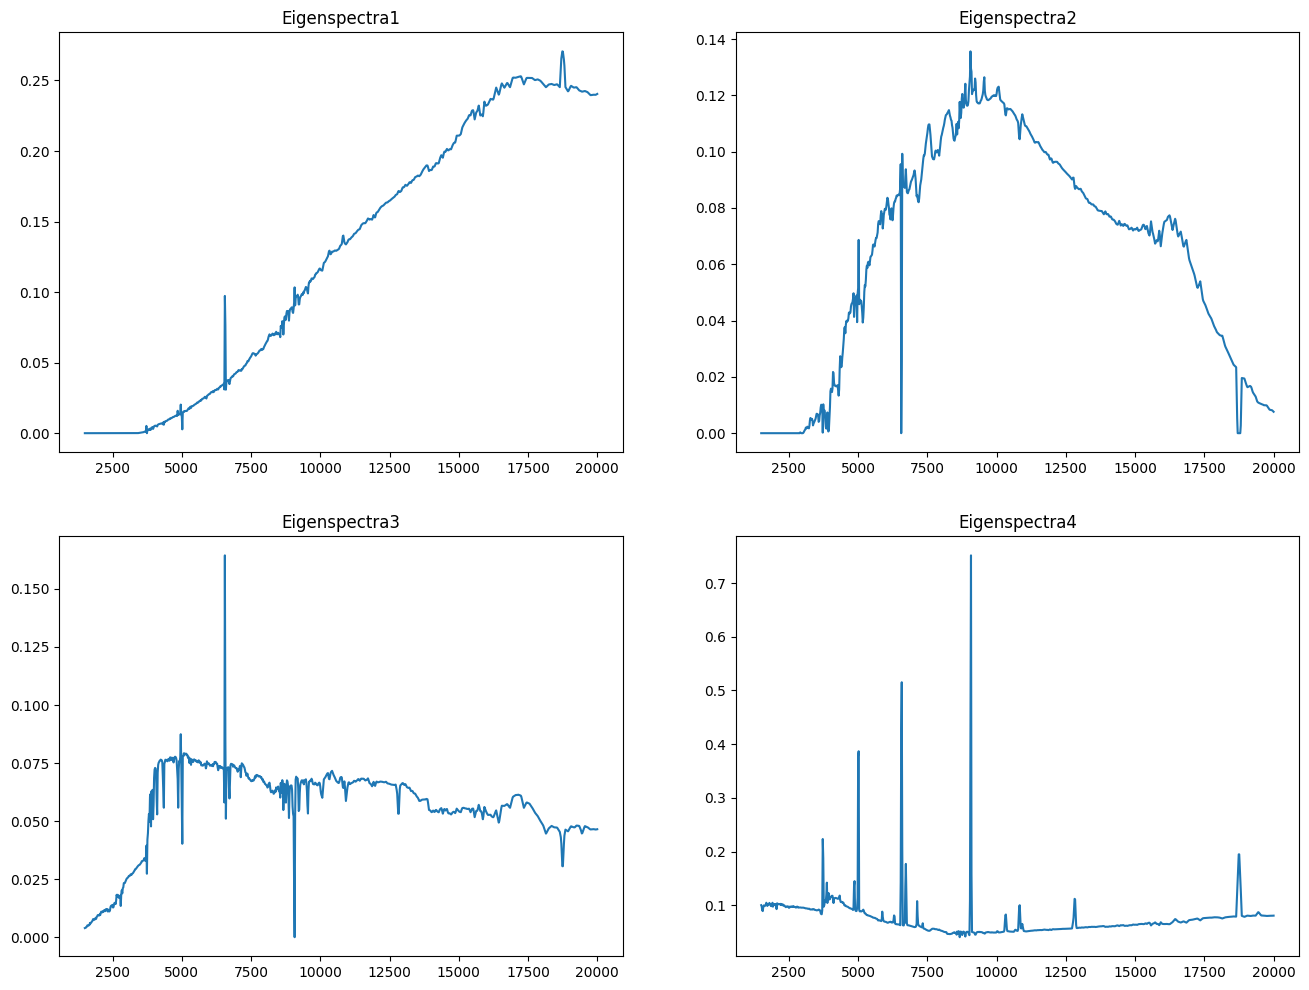

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axs=axes.flatten()
for i in range(len(H)):
    ax = axs[i]
    ax.plot(wave_grid, H[i])
    ax.set_title(f'Eigenspectra{i+1}')

## Method 1: COSMOS2020 

In [1]:
from sedpy import observate
from sedpy.observate import load_filters, getSED

C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sedpy\observate.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename, resource_listdir


In [2]:
import pyarrow.feather as feather

tbl = feather.read_table("cosmos_subset.feather", memory_map=True)
df = tbl.to_pandas(ignore_metadata=True)  # avoids extension dtype tricks

In [3]:
fil=['galex_NUV','galex_FUV','hsc_g','hsc_r','hsc_i','hsc_z','hsc_y','subaru_suprimecam_B','subaru_suprimecam_V','subaru_suprimecam_ia484','subaru_suprimecam_ia527','subaru_suprimecam_ia624','subaru_suprimecam_ia679','subaru_suprimecam_ia738',
 'subaru_suprimecam_ia767','subaru_suprimecam_ip','subaru_suprimecam_zp','subaru_suprimecam_rp','vista_vircam_H','vista_vircam_J','vista_vircam_Y','vista_vircam_Ks','acs_wfc_f814w']

In [15]:
import pandas as pd
df_b = pd.read_feather("cosmos_used_filter.feather")

In [17]:
df_b=df_b.drop('Y_IMAGE',axis=1)

In [18]:
df_b.columns

Index(['GALEX_NUV_FLUX', 'GALEX_FUV_FLUX', 'HSC_g_FLUX_APER2',
       'HSC_r_FLUX_APER2', 'HSC_i_FLUX_APER2', 'HSC_z_FLUX_APER2',
       'HSC_y_FLUX_APER2', 'SC_B_FLUX_APER2', 'SC_V_FLUX_APER2',
       'SC_IA484_FLUX_APER2', 'SC_IA527_FLUX_APER2', 'SC_IA624_FLUX_APER2',
       'SC_IA679_FLUX_APER2', 'SC_IA738_FLUX_APER2', 'SC_IA767_FLUX_APER2',
       'SC_ip_FLUX_APER2', 'SC_zp_FLUX_APER2', 'SC_rp_FLUX_APER2',
       'UVISTA_H_FLUX_APER2', 'UVISTA_J_FLUX_APER2', 'UVISTA_Y_FLUX_APER2',
       'UVISTA_Ks_FLUX_APER2', 'ACS_F814W_FLUX'],
      dtype='object')

## Least Sqaures method

In [16]:
import pandas as pd

# Your two DataFrames:
# df_flux: the one with only fluxes (currently loaded)
# df_err: the one that already contains the corresponding error columns

def convert_to_err_colname(colname):
    parts = colname.replace('FLUX','FLUXERR')
    return parts
    

# Create mapping from flux column → error column
col_mapping = {}
for col in df_b.columns:
    err_col = convert_to_err_colname(col)
    if err_col in df.columns:
        col_mapping[col] = err_col
df_err=pd.DataFrame()
# Copy over matching error columns
for flux_col, err_col in col_mapping.items():
    df_err[err_col] = df[err_col]

print(f"Copied {len(col_mapping)} error columns from df_err to df_flux.")


Copied 23 error columns from df_err to df_flux.


In [28]:
df_err.to_feather("cosmos_used_error.feather")

In [18]:
E = df_err[df_err.columns].to_numpy(float)


In [22]:
E = np.nan_to_num(E, nan=1e6)

In [24]:
import numpy as np
import pandas as pd
from sedpy.observate import load_filters, getSED

filters = load_filters(fil)
X_list = [getSED(wave_grid, h, filters, linear_flux=True) * 3631*1e6 for h in H]
X = np.array(X_list).T  # shape: (n_bands, n_components)

Y = df_b[df_b.columns].to_numpy(float)
Y = np.nan_to_num(Y, nan=0.0)

def fit_coeffs_vectorized(X, Y, E, chunk_size=100000):
    B, K = X.shape
    _, N = Y.shape
    A = np.zeros((K, N))
    eps = 1e-12

    for start in range(0, N, chunk_size):
        #print(start)
        stop = min(start + chunk_size, N)
        y = Y[:, start:stop]              # (B, n_chunk)
        w = 1.0 / np.maximum(E[:, start:stop], eps)**2

        sqrtw = np.sqrt(w)                        # (B,n_chunk)
        Xw = X[:, :, None] * sqrtw[:, None, :]    # (B,K,n_chunk)
        yw = y * sqrtw                            # (B,n_chunk)

        XtWX = np.einsum("bkn,bmn->kmn", Xw, Xw)  # (K,K,n_chunk)
        XtWy = np.einsum("bkn,bn->kn", Xw, yw)    # (K,n_chunk)

        # Solve per galaxy
        for j in range(stop - start):
            A[:, start + j] = np.linalg.pinv(XtWX[:, :, j]) @ XtWy[:, j]

    return A




B=fit_coeffs_vectorized(X,Y.T,E.T).T

In [27]:
import pickle
with open('saved_list.pkl', 'wb') as f:
    pickle.dump(B, f)

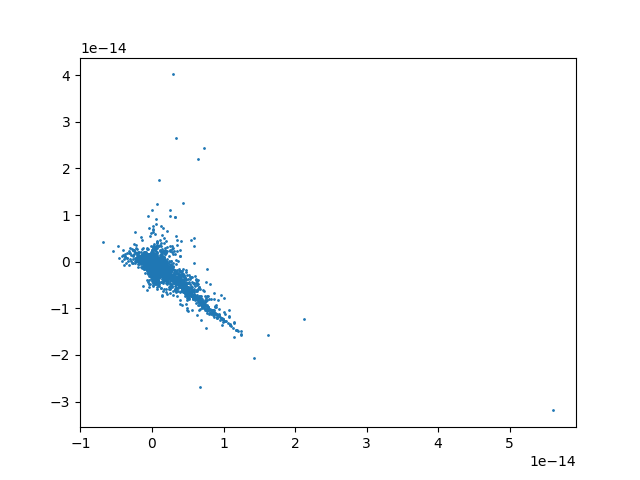

In [310]:
B = np.array(B)

# Extract all x and y coordinates in a single operation
x_coords = B[:, 0]
y_coords = B[:, 1]

# FAST: Creates a single plot object for all points
plt.figure()
plt.scatter(x_coords, y_coords, s=1) # s=1 makes the points smaller for large datasets
plt.show()

In [ ]:
%matplotlib inline

In [256]:
# --- GMM on a list-of-lists of 4D coefficients ---

import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler


def fit_gmm_initial_from_list(C_list, K_grid=range(1, 13), n_init=2, max_samples=100000):

    # Subsample
    C_list = np.array(C_list)
    if C_list.shape[0] > max_samples:
        rng = np.random.default_rng(42)
        idx = rng.choice(C_list.shape[0], max_samples, replace=False)
        C_list = C_list[idx]

    # Standardize
    scaler = StandardScaler()
    X = scaler.fit_transform(C_list)

    results = []
    best_model, best_bic = None, np.inf
    for K in K_grid:
        print(f"Fitting GMM with K={K}")
        gm = GaussianMixture(n_components=K, covariance_type='diag', n_init=n_init, init_params="kmeans", random_state=42).fit(X)
        bic = gm.bic(X)
        aic = gm.aic(X)
        results.append((K, bic, aic, gm))
        if bic < best_bic:
            best_bic, best_model = bic, gm

    info = {
        "chosen_K": best_model.n_components,
        "best_bic": best_bic,
        "results": results
    }

    return best_model, scaler, info

    
best_model, scaler, info = fit_gmm_initial_from_list(B)
print("Chosen K:", info["chosen_K"])


'''nsamples=50
Z = best_model.sample(nsamples)[0]          
A_sim = scaler.inverse_transform(Z)'''


Fitting GMM with K=1
Fitting GMM with K=2
Fitting GMM with K=3
Fitting GMM with K=4
Fitting GMM with K=5
Fitting GMM with K=6
Fitting GMM with K=7
Fitting GMM with K=8
Fitting GMM with K=9
Fitting GMM with K=10
Fitting GMM with K=11
Fitting GMM with K=12
Chosen K: 12


'nsamples=50\nZ = best_model.sample(nsamples)[0]          \nA_sim = scaler.inverse_transform(Z)'

In [258]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [259]:
import pickle

# Save
with open("best_gmm_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

## Method 2: extreme deconvolution

In [4]:
import pandas as pd
df3 = pd.read_feather("cosmos_used_filter.feather")

In [5]:
import pandas as pd

# Your two DataFrames:
# df_flux: the one with only fluxes (currently loaded)
# df_err: the one that already contains the corresponding error columns

def convert_to_err_colname(colname):
    parts = colname.replace('FLUX','FLUXERR')
    return parts
    

# Create mapping from flux column → error column
col_mapping = {}
for col in df3.columns:
    err_col = convert_to_err_colname(col)
    if err_col in df.columns:
        col_mapping[col] = err_col

# Copy over matching error columns
for flux_col, err_col in col_mapping.items():
    df3[err_col] = df[err_col]

print(f"Copied {len(col_mapping)} error columns from df_err to df_flux.")


Copied 25 error columns from df_err to df_flux.


In [22]:
df3=df3.drop('X_IMAGE',axis=1)

In [7]:
#df_b=df_b.drop('Y_IMAGE',axis=1)
df3.columns

Index(['X_IMAGE', 'GALEX_NUV_FLUX', 'GALEX_FUV_FLUX', 'HSC_g_FLUX_APER2',
       'HSC_r_FLUX_APER2', 'HSC_i_FLUX_APER2', 'HSC_z_FLUX_APER2',
       'HSC_y_FLUX_APER2', 'SC_B_FLUX_APER2', 'SC_V_FLUX_APER2',
       'SC_IA484_FLUX_APER2', 'SC_IA527_FLUX_APER2', 'SC_IA624_FLUX_APER2',
       'SC_IA679_FLUX_APER2', 'SC_IA738_FLUX_APER2', 'SC_IA767_FLUX_APER2',
       'SC_ip_FLUX_APER2', 'SC_zp_FLUX_APER2', 'SC_rp_FLUX_APER2',
       'UVISTA_H_FLUX_APER2', 'UVISTA_J_FLUX_APER2', 'UVISTA_Y_FLUX_APER2',
       'UVISTA_Ks_FLUX_APER2', 'ACS_F814W_FLUX', 'GALEX_NUV_FLUXERR',
       'GALEX_FUV_FLUXERR', 'HSC_g_FLUXERR_APER2', 'HSC_r_FLUXERR_APER2',
       'HSC_i_FLUXERR_APER2', 'HSC_z_FLUXERR_APER2', 'HSC_y_FLUXERR_APER2',
       'SC_B_FLUXERR_APER2', 'SC_V_FLUXERR_APER2', 'SC_IA484_FLUXERR_APER2',
       'SC_IA527_FLUXERR_APER2', 'SC_IA624_FLUXERR_APER2',
       'SC_IA679_FLUXERR_APER2', 'SC_IA738_FLUXERR_APER2',
       'SC_IA767_FLUXERR_APER2', 'SC_ip_FLUXERR_APER2', 'SC_zp_FLUXERR_APER2',
     

In [36]:
import numpy as np
from sedpy.observate import getSED, load_filters

# -----------------------------
# Setup
# -----------------------------

fil = ['galex_NUV','galex_FUV','hsc_g','hsc_r','hsc_i','hsc_z','hsc_y',
       'subaru_suprimecam_B','subaru_suprimecam_V','subaru_suprimecam_ia484',
       'subaru_suprimecam_ia527','subaru_suprimecam_ia624','subaru_suprimecam_ia679',
       'subaru_suprimecam_ia738','subaru_suprimecam_ia767','subaru_suprimecam_ip',
       'subaru_suprimecam_zp','subaru_suprimecam_rp','vista_vircam_H','vista_vircam_J',
       'vista_vircam_Y','vista_vircam_Ks','acs_wfc_f814w']

filters = load_filters(fil)  # Load filter curves
F_matrix = np.array([getSED(wave_grid, H_k, filters, linear_flux=True)* 3631*1e6 for H_k in H]).T  # (M, K)

# Observed fluxes and errors
Y = np.nan_to_num(df3[df_b.columns].to_numpy(float), nan=0.0)       # (N, M)
S = np.nan_to_num(df3[df3.columns[23:]].to_numpy(float), nan=1e6)   # (N, M)
R = S**2
N, M = Y.shape
K = F_matrix.shape[1]

# Prior initialization
mean_prior = np.zeros(K)
cov_prior = np.eye(K)
inv_cov_prior = np.linalg.inv(cov_prior)

# EM loop
num_iterations = 50
convergence_threshold = 1e-20
batch_size = 10000
FT = F_matrix.T  # (K x M)

print("--- XD with Batching and Woodbury identity ---")

for it in range(num_iterations):
    mu_old = mean_prior.copy()
a
    # Sufficient statistics
    sum_mean = np.zeros(K)
    sum_cov = np.zeros((K, K))
    sum_outer = np.zeros((K, K))

    # Batch loop
    for b in range(0, N, batch_size):
        i_end = min(b + batch_size, N)
        Y_batch = Y[b:i_end]
        R_batch = R[b:i_end]
        W = 1.0 / R_batch                          # (B, M)
        W_Y = W * Y_batch                          # (B, M)

        A = np.einsum('km,bm,mj->bkj', FT, W, F_matrix)
        A += inv_cov_prior[None, :, :]             # (B, K, K)

        rhs = W_Y @ F_matrix + (inv_cov_prior @ mean_prior)[None, :]  # (B, K)

        for i in range(i_end - b):
            try:
                Ainv = np.linalg.inv(A[i])
            except np.linalg.LinAlgError:
                Ainv = np.linalg.pinv(A[i])

            b_i = Ainv @ rhs[i]

            sum_mean += b_i
            sum_cov += Ainv
            sum_outer += np.outer(b_i, b_i)

    # M-step
    mean_prior = sum_mean / N
    cov_prior = (sum_cov + sum_outer )/ N - np.outer(mean_prior, mean_prior)
    inv_cov_prior = np.linalg.inv(cov_prior)

    delta_mu = np.linalg.norm(mean_prior - mu_old)
    print(f"Iter {it+1:02d} | Δμ = {delta_mu:.3e}")
    if delta_mu < convergence_threshold:
        break

# Final output
print("\nFinal Prior Mean:")
print(mean_prior)
print("\nFinal Prior Covariance:")
print(cov_prior)


C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sedpy\observate.py:484: RuntimeWarning: divide by zero encountered in log10
  return -2.5 * np.log10(counts / self.ab_zero_counts)


--- XD with Batching and Woodbury identity ---
Iter 01 | Δμ = 1.223e-17
Iter 02 | Δμ = 9.801e-19
Iter 03 | Δμ = 1.087e-20
Iter 04 | Δμ = 2.055e-20
Iter 05 | Δμ = 7.478e-23

Final Prior Mean:
[ 3.04611263e-18 -1.61108748e-18  1.16478862e-17 -2.93271070e-18]

Final Prior Covariance:
[[ 1.84662957e-32 -1.88661604e-32  1.73518151e-32 -4.61214419e-33]
 [-1.88661604e-32  2.96753379e-32 -3.42471453e-32  7.68685080e-33]
 [ 1.73518151e-32 -3.42471453e-32  1.25035052e-31 -7.62951815e-32]
 [-4.61214419e-33  7.68685080e-33 -7.62951815e-32  6.17592383e-32]]


### Verification

In [45]:
df4=df[['HSC_g_FLUX_APER2','HSC_r_FLUX_APER2','HSC_i_FLUX_APER2','HSC_g_FLUXERR_APER2','HSC_r_FLUXERR_APER2','HSC_i_FLUXERR_APER2']]
df4=df4.to_numpy()
df4

array([[9.7519783e+01, 2.2997720e+02, 3.3389758e+02, 1.2325739e-01,
        1.8475455e-01, 2.0034683e-01],
       [1.0509821e+02, 1.1825040e+02, 1.1425900e+02, 1.2849218e-01,
        1.3176109e-01, 1.1680809e-01],
       [2.1367700e+00, 4.9615660e+00, 7.9533157e+00, 1.8433090e-02,
        2.7381249e-02, 3.1572483e-02],
       ...,
       [          nan,           nan, 1.5795746e-04,           nan,
                  nan, 1.3465100e-04],
       [          nan,           nan, 1.3153009e-03,           nan,
                  nan, 3.8855462e-04],
       [          nan,           nan, 1.5990274e-02,           nan,
                  nan, 1.3547760e-03]], dtype=float32)

In [50]:
import pickle
with open("best_gmm_model.pkl", "rb") as f:
    best_model = pickle.load(f)

from joblib import load

scaler = load("scaler.pkl")



C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sedpy\observate.py:484: RuntimeWarning: invalid value encountered in log10
  return -2.5 * np.log10(counts / self.ab_zero_counts)
C:\Users\pranav\AppData\Local\Temp\ipykernel_48064\3340287511.py:29: RuntimeWarning: invalid value encountered in log10
  real_color1 = -2.5 * np.log10(real_phot[:, g] / real_phot[:, r])
C:\Users\pranav\AppData\Local\Temp\ipykernel_48064\3340287511.py:30: RuntimeWarning: invalid value encountered in log10
  real_color2 = -2.5 * np.log10(real_phot[:, r] / real_phot[:, i])
C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


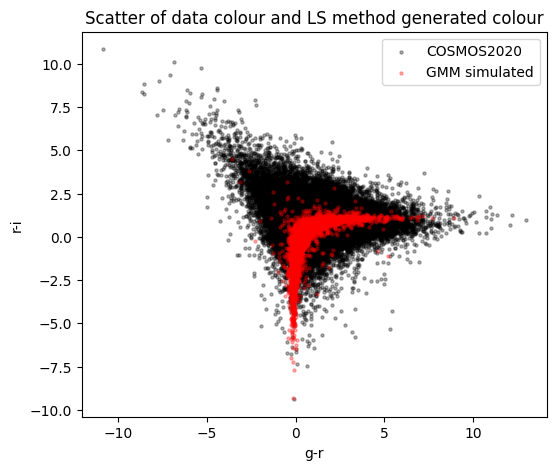

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sedpy.observate import load_filters, getSED
from sklearn.mixture import GaussianMixture

# --- 1. Sample from your GMM in coefficient space ---
def sample_coeffs_from_gmm(gmm, scaler,n_samples, random_state=0):
    """Draw samples of PCA/NMF coefficients from fitted GMM."""
    c_sim, _ = gmm.sample(n_samples)
    c=scaler.inverse_transform(c_sim)
    return c

# --- 2. Rebuild SEDs from coefficients ---
def rebuild_seds(coeffs, components):
    return coeffs @ components  # matrix multiply

# --- 3. Project SEDs into photometry ---
def seds_to_photometry(seds, wavelengths, filter_names):
    filters = load_filters(filter_names)
    phot = np.array([getSED(wavelengths, s, filters) for s in seds])
    return phot

# --- 4. Comparison plotting ---
def compare_color_color(real_phot, sim_phot, bands=('HSC_g_FLUX_APER2','HSC_r_FLUX_APER2','HSC_i_FLUX_APER2')):
    """Quick color-color plot."""
    # Example: g-r vs r-i
    g, r, i = [bands.index(b) for b in bands]

    real_color1 = -2.5 * np.log10(real_phot[:, g] / real_phot[:, r])
    real_color2 = -2.5 * np.log10(real_phot[:, r] / real_phot[:, i])
    sim_color1  = sim_phot[:, g] - sim_phot[:, r]
    sim_color2  = sim_phot[:, r] - sim_phot[:, i]

    plt.figure(figsize=(6,5))
    plt.scatter(real_color1, real_color2, s=5, c='k', alpha=0.3, label='COSMOS2020')
    plt.scatter(sim_color1, sim_color2, s=5, c='red', alpha=0.3, label='GMM simulated')
    plt.xlabel('g-r')
    plt.ylabel('r-i')
    plt.title('Scatter of data colour and LS method generated colour')
    plt.legend()
    plt.show()
    return sim_color1,sim_color2
# ------------------- Example pipeline -------------------

# Step 1: sample from GMM
c_sim = sample_coeffs_from_gmm(best_model,scaler, n_samples=100000)

# Step 2: rebuild synthetic SEDs
seds_sim = rebuild_seds(c_sim, H)

# Step 3: project to photometry
filter_names = ['hsc_g','hsc_r','hsc_i']  # replace with COSMOS/HSC bands you use
phot_sim_LS = seds_to_photometry(seds_sim, wave_grid, filter_names)

# Do the same projection for your real data if needed
# (if you already have COSMOS2020 magnitudes in same bands, just load them)


c1,c2=compare_color_color(df4, phot_sim_LS)


In [19]:
bands=('HSC_g_FLUX_APER2','HSC_r_FLUX_APER2','HSC_i_FLUX_APER2')
g, r, i = [bands.index(b) for b in bands]

real_color1 = -2.5 * np.log10(df4[:, g] / df4[:, r])
real_color2 = -2.5 * np.log10(df4[:, r] / df4[:, i])

C:\Users\pranav\AppData\Local\Temp\ipykernel_20192\336316599.py:4: RuntimeWarning: invalid value encountered in log10
  real_color1 = -2.5 * np.log10(df4[:, g] / df4[:, r])
C:\Users\pranav\AppData\Local\Temp\ipykernel_20192\336316599.py:5: RuntimeWarning: invalid value encountered in log10
  real_color2 = -2.5 * np.log10(df4[:, r] / df4[:, i])


In [20]:
errbands=('HSC_g_FLUXERR_APER2','HSC_r_FLUXERR_APER2','HSC_i_FLUXERR_APER2')
gerr, rerr, ierr = [errbands.index(b)+3 for b in errbands]
g_r_err = np.sqrt(df4[:,gerr]**2 + df4[:,rerr]**2)
r_i_err = np.sqrt(df4[:,rerr]**2 + df4[:,ierr]**2)
mask1 = np.isfinite(g_r_err) & np.isfinite(r_i_err)
gr_err=g_r_err[mask1]
ri_err=r_i_err[mask1]

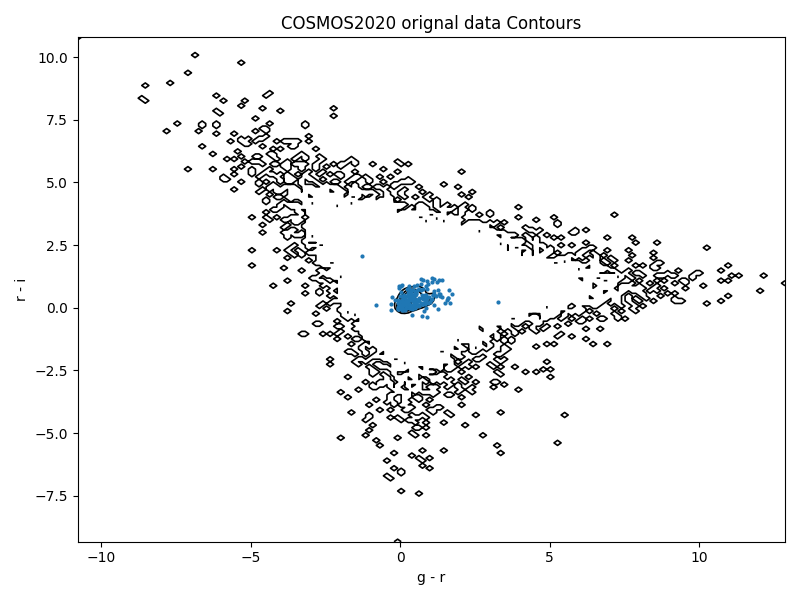

In [313]:
import matplotlib.pyplot as plt

# Set up 2D histogram

mask = np.isfinite(real_color1) & np.isfinite(real_color2)
real_color1_clean = real_color1[mask]
real_color2_clean = real_color2[mask]
H, xedges, yedges = np.histogram2d(real_color1_clean, real_color2_clean, bins=200)

# Coordinates of centers of bins
xcenters = 0.5 * (xedges[1:] + xedges[:-1])
ycenters = 0.5 * (yedges[1:] + yedges[:-1])
X, Y = np.meshgrid(xcenters, ycenters)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot density contours
cs = ax.contour(X, Y, H.T, levels=10, colors='black', linewidths=1.2)

# Or: filled contours
# cs = ax.contourf(X, Y, H.T, levels=15, cmap='Greys')
rng = np.random.default_rng(42)
subset = rng.choice(len(real_color1), size=200, replace=False)

ax.errorbar(real_color1[subset], real_color2[subset],
            xerr=gr_err[subset], yerr=ri_err[subset],
            fmt='o', ecolor='lightgray', elinewidth=0.8, ms=2, alpha=1,
            label='photometry with errors')
# Add scatter (optional)
%matplotlib widget
ax.set_xlabel('g - r')
ax.set_ylabel('r - i')
ax.set_title('COSMOS2020 orignal data Contours')
plt.tight_layout()
plt.show()


# Noise Model

C:\Users\pranav\AppData\Local\Temp\ipykernel_20192\4004587400.py:8: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(alpha*f + beta)
C:\Users\pranav\AppData\Local\Temp\ipykernel_20192\4004587400.py:12: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(noise_model, f, e, p0=[1.0, 1.0])


alpha, beta = [2.0558123e-04 8.9164868e-05]
alpha, beta = [1.49425017e-04 5.68665621e-05]
alpha, beta = [1.20891800e-04 8.83934351e-05]


C:\Users\pranav\AppData\Local\Temp\ipykernel_20192\4004587400.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


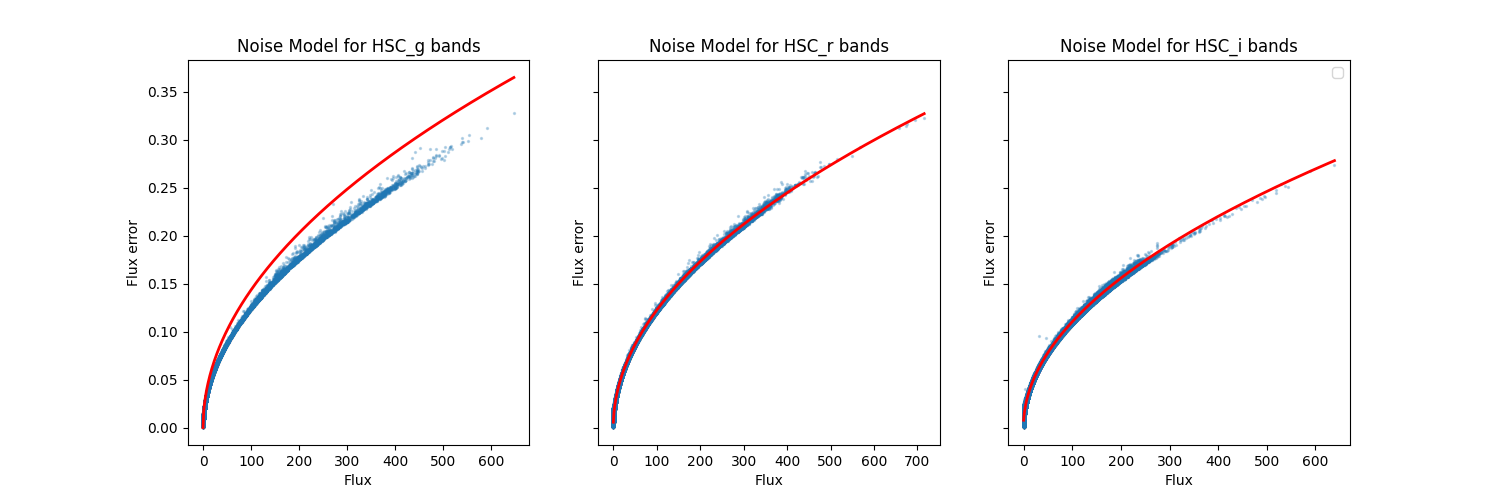

In [314]:
from scipy.optimize import curve_fit
mag_list = [df4[:,0], df4[:,1], df4[:,2]]
err_list = [df4[:,3], df4[:,4], df4[:,5]]
filter_names = ["HSC_g", "HSC_r", "HSC_i"]
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
opt=[]
def noise_model(f, alpha, beta):
    return np.sqrt(alpha*f + beta)
for ax, mag, err, name in zip(axes, mag_list, err_list, filter_names):
    mask = np.isfinite(mag) & np.isfinite(err) 
    f = mag[mask]; e = err[mask]
    popt, pcov = curve_fit(noise_model, f, e, p0=[1.0, 1.0])
    print("alpha, beta =", popt)
    opt.append(popt)
    fgrid = np.linspace(np.nanmin(f), np.nanmax(f), 500)
    ax.scatter(f, e, s=2, alpha=0.25)
    ax.plot(fgrid, noise_model(fgrid, *popt), 'r', lw=2)
    #ax.xscale("log"); ax.yscale("log")
    ax.set_xlabel("Flux"); ax.set_ylabel("Flux error")
    ax.set_title(f'Noise Model for {name} bands')
plt.legend()
plt.show()


In [205]:
opt

[array([2.0558123e-04, 8.9164868e-05]),
 array([1.49425017e-04, 5.68665621e-05]),
 array([1.20891800e-04, 8.83934351e-05])]

In [ ]:
def color_cov_from_banderrs(sig_g, sig_r, sig_i):
    var_gr = sig_g**2 + sig_r**2
    var_ri = sig_r**2 + sig_i**2
    return var_gr, var_ri



In [286]:
sig_g_LS = noise_model(10**(-phot_sim_LS[:,0]/2.5)*3631,*opt[0])
sig_r_LS = noise_model(10**(-phot_sim_LS[:,1]/2.5)*3631,*opt[1])
sig_i_LS = noise_model(10**(-phot_sim_LS[:,2]/2.5)*3631,*opt[2])

sig_g_XD = noise_model(10**(-phot_sim_XD[:,0]/2.5)*3631,*opt[0])
sig_r_XD = noise_model(10**(-phot_sim_XD[:,1]/2.5)*3631,*opt[1])
sig_i_XD = noise_model(10**(-phot_sim_XD[:,2]/2.5)*3631,*opt[2])

var_gr_LS, var_ri_LS= color_cov_from_banderrs(sig_g_LS, sig_r_LS, sig_i_LS)
var_gr_XD, var_ri_XD = color_cov_from_banderrs(sig_g_XD, sig_r_XD, sig_i_XD)

mask2 = np.isfinite(var_gr_LS) & np.isfinite(var_ri_LS)
var_gr_LS=var_gr_LS[mask2]
var_ri_LS=var_ri_LS[mask2]

mask3 = np.isfinite(var_gr_XD) & np.isfinite(var_ri_XD)
var_gr_XD=var_gr_XD[mask3]
var_ri_XD=var_ri_XD[mask3]

In [241]:
sig_g_XD

array([          nan,  957.72203683,           nan, ..., 2589.41673394,
       2344.11541525,           nan])

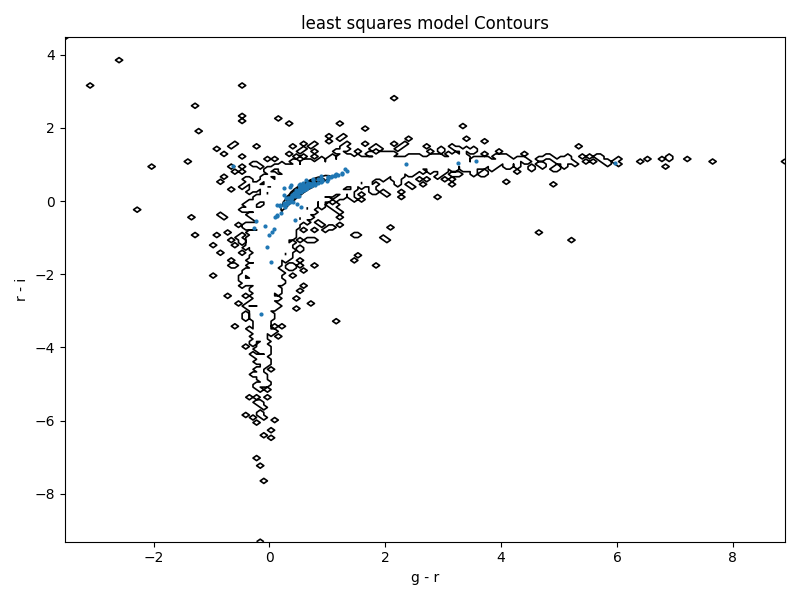

In [315]:
import matplotlib.pyplot as plt

# Set up 2D histogram

mask = np.isfinite(c1) & np.isfinite(c2)
c1_clean = c1[mask]
c2_clean = c2[mask]
H, xedges, yedges = np.histogram2d(c1_clean, c2_clean, bins=200)

# Coordinates of centers of bins
xcenters = 0.5 * (xedges[1:] + xedges[:-1])
ycenters = 0.5 * (yedges[1:] + yedges[:-1])
X, Y = np.meshgrid(xcenters, ycenters)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot density contours
cs = ax.contour(X, Y, H.T, levels=10, colors='black', linewidths=1.2)

# Or: filled contours
# cs = ax.contourf(X, Y, H.T, levels=15, cmap='Greys')
#rng = np.random.default_rng(42
subset = rng.choice(len(var_gr_LS), size=200, replace=False)

ax.errorbar(c1[subset], c2[subset],
            xerr=var_gr_LS[subset], yerr=var_ri_LS[subset],
            fmt='o', ecolor='lightgray', elinewidth=0.8, ms=2, alpha=1,
            label='photometry with errors')
# Add scatter (optional)
%matplotlib widget
ax.set_xlabel('g - r')
ax.set_ylabel('r - i')
ax.set_title('least squares model Contours')
plt.tight_layout()
plt.show()


In [4]:
mean_prior=[ 3.04611263e-18 ,-1.61108748e-18,  1.16478862e-17, -2.93271070e-18]

cov_prior=[[ 1.84662957e-32 ,-1.88661604e-32 , 1.73518151e-32, -4.61214419e-33],
 [-1.88661604e-32 , 2.96753379e-32 ,-3.42471453e-32,  7.68685080e-33],
 [ 1.73518151e-32 ,-3.42471453e-32,  1.25035052e-31 ,-7.62951815e-32],
 [-4.61214419e-33 , 7.68685080e-33, -7.62951815e-32 , 6.17592383e-32]]

In [20]:
import numpy as np
rng = np.random.default_rng()
p=rng.multivariate_normal(mean_prior, cov_prior, size=1000)
p=p.flatten()
min(p),max(p),np.mean(p),np.median(p)

(-1.014043932761353e-15,
 1.0348343120267532e-15,
 1.5146522042964605e-18,
 -2.018224537991341e-18)

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sedpy.observate import load_filters, getSED
from sklearn.mixture import GaussianMixture

# --- 1. Sample from your GMM in coefficient space ---
def sample_coeffs_from_gmm_XD(mean, cov, n_samples, random_state=0):
    rng = np.random.default_rng(random_state)
    return rng.multivariate_normal(mean, cov, size=n_samples)

# --- 2. Rebuild SEDs from coefficients ---
def rebuild_seds(coeffs, components):
    return coeffs @ components  # matrix multiply

# --- 3. Project SEDs into photometry ---
def seds_to_photometry(seds, wavelengths, filter_names):
    filters = load_filters(filter_names)
    phot = np.array([getSED(wavelengths, s, filters) for s in seds])
    return phot

# --- 4. Comparison plotting ---
def compare_color_color(real_phot, sim_phot, bands=('HSC_g_FLUX_APER2','HSC_r_FLUX_APER2','HSC_i_FLUX_APER2')):
    """Quick color-color plot."""
    # Example: g-r vs r-i
    g, r, i = [bands.index(b) for b in bands]

    real_color1 = -2.5 * np.log10(real_phot[:, g] / real_phot[:, r])
    real_color2 = -2.5 * np.log10(real_phot[:, r] / real_phot[:, i])
    sim_color1  = sim_phot[:, g] - sim_phot[:, r]
    sim_color2  = sim_phot[:, r] - sim_phot[:, i]

    plt.figure(figsize=(6,5))
    plt.scatter(real_color1, real_color2, s=5, c='k', alpha=0.3, label='COSMOS2020')
    plt.scatter(sim_color1, sim_color2, s=5, c='red', alpha=0.3, label='GMM simulated')
    plt.title('Scatter of data colour and XD method generated colour')
    plt.xlabel('g-r')
    plt.ylabel('r-i')
    plt.legend()
    plt.show()
    return sim_color1, sim_color2
# ------------------- Example pipeline -------------------

# Step 1: sample from GMM
c_sim = sample_coeffs_from_gmm_XD(mean_prior, cov_prior, n_samples=100000)

# Step 2: rebuild synthetic SEDs
seds_sim = rebuild_seds(c_sim, H)

# Step 3: project to photometry
filter_names = ['hsc_g','hsc_r','hsc_i']  # replace with COSMOS/HSC bands you use
phot_sim_XD = seds_to_photometry(seds_sim, wave_grid, filter_names)

# Do the same projection for your real data if needed
# (if you already have COSMOS2020 magnitudes in same bands, just load them)

c3,c4=compare_color_color(df4, phot_sim_XD)


NameError: name 'H' is not defined

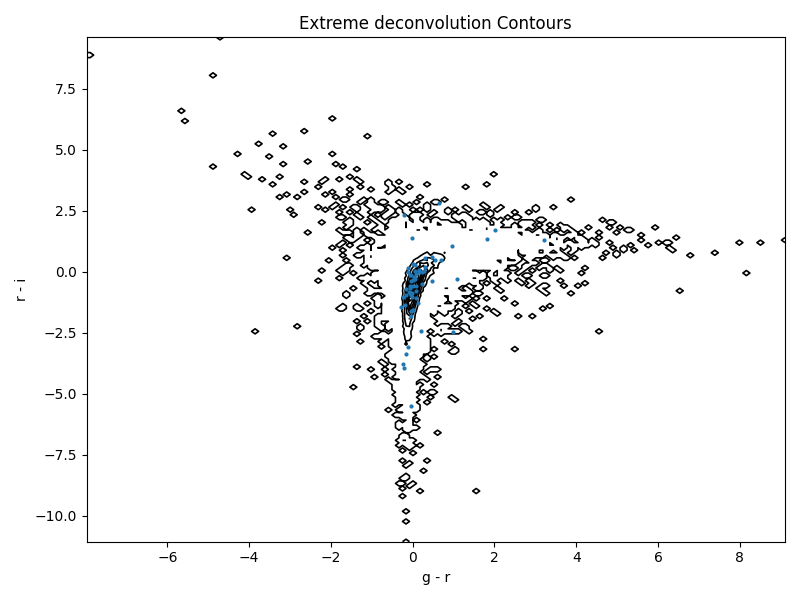

In [319]:
import matplotlib.pyplot as plt

# Set up 2D histogram

mask = np.isfinite(c3) & np.isfinite(c4)
c3_clean = c3[mask]
c4_clean = c4[mask]
H, xedges, yedges = np.histogram2d(c3_clean, c4_clean, bins=200)

# Coordinates of centers of bins
xcenters = 0.5 * (xedges[1:] + xedges[:-1])
ycenters = 0.5 * (yedges[1:] + yedges[:-1])
X, Y = np.meshgrid(xcenters, ycenters)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot density contours
cs = ax.contour(X, Y, H.T, levels=10, colors='black', linewidths=1.2)

# Or: filled contours
# cs = ax.contourf(X, Y, H.T, levels=15, cmap='Greys')
rng = np.random.default_rng(42)
subset = rng.choice(len(var_gr_XD), size=200, replace=False)

ax.errorbar(c3[subset], c4[subset],
            xerr=var_gr_XD[subset], yerr=var_ri_XD[subset],
            fmt='o', ecolor='lightgray', elinewidth=0.8, ms=2, alpha=1,
            label='photometry with errors')
# Add scatter (optional)
%matplotlib widget
ax.set_xlabel('g - r')
ax.set_ylabel('r - i')
ax.set_title('Extreme deconvolution Contours')
plt.tight_layout()
plt.show()


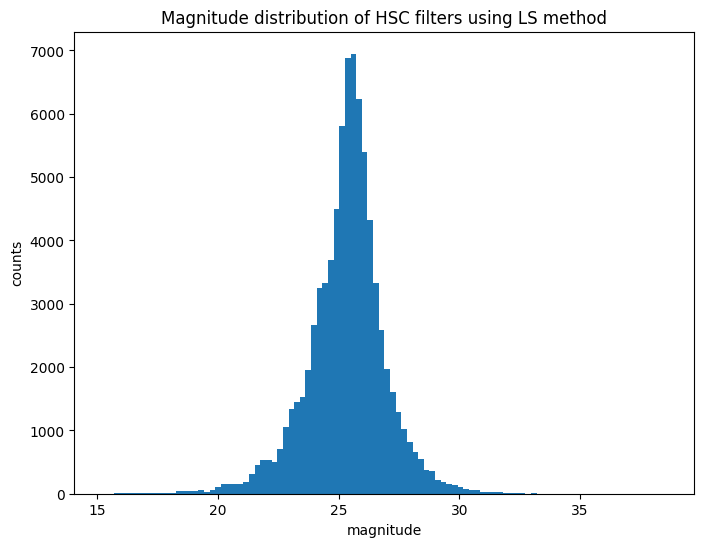

In [52]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(phot_sim_LS[:,2],bins=100)
plt.title('Magnitude distribution of HSC filters using LS method')
plt.xlabel("magnitude")
plt.ylabel('counts')
plt.show()

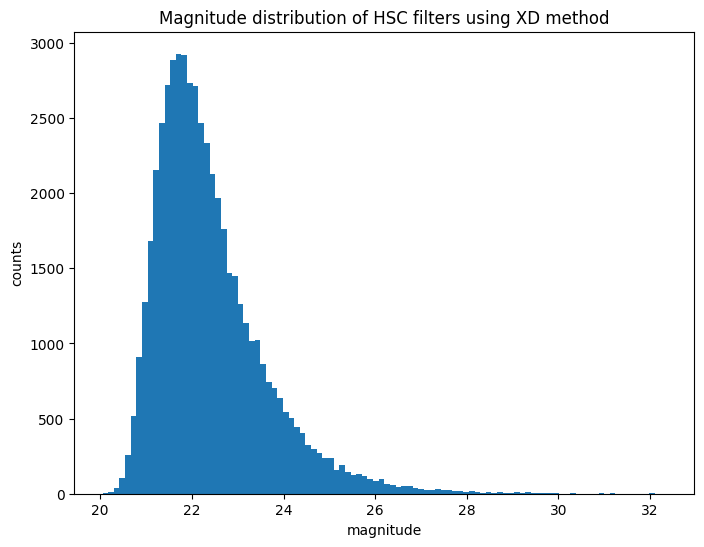

In [53]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(phot_sim_XD[:,0],bins=100)
plt.title('Magnitude distribution of HSC filters using XD method')
plt.xlabel("magnitude")
plt.ylabel('counts')
plt.show()

In [247]:
best_model

GaussianMixture(covariance_type='diag', n_components=12, n_init=2,
                random_state=42)